# Final Analysis: Corrected Causal Model

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, invgamma, beta as beta_dist

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

# Load Data
data_dir = '../data' if os.path.exists('../data/sp500_data.csv') else 'data'
sp500_df = pd.read_csv(f"{data_dir}/sp500_data.csv")
nifty50_df = pd.read_csv(f"{data_dir}/nifty50_data.csv")

# FORCING the dates to be proper DatetimeIndex objects and stripping timezones
sp500_df['Date'] = pd.to_datetime(sp500_df['Date'], utc=True).dt.tz_localize(None)
sp500_df = sp500_df.set_index('Date').sort_index()

nifty50_df['Date'] = pd.to_datetime(nifty50_df['Date'], utc=True).dt.tz_localize(None)
nifty50_df = nifty50_df.set_index('Date').sort_index()

sp500_df = sp500_df.dropna(subset=['Log_Return'])
nifty50_df = nifty50_df.dropna(subset=['Log_Return'])

print(f"S&P 500 weekly obs: {len(sp500_df)}")
print(f"NIFTY 50 weekly obs: {len(nifty50_df)}")
print("Data loaded and dates fixed successfully!")

S&P 500 weekly obs: 1110
NIFTY 50 weekly obs: 969
Data loaded and dates fixed successfully!


In [2]:
def ffbs(y, mu, sig2, p_diag):
    T = len(y)
    P_mat = np.array([[p_diag[0], 1 - p_diag[0]],
                      [1 - p_diag[1], p_diag[1]]])
    P_filt = np.zeros((T, 2))
    P_filt[0] = [0.5, 0.5]
    
    # Forward Pass (Filtered Probabilities)
    for t in range(1, T):
        P_pred = P_mat.T @ P_filt[t - 1]
        L = np.array([norm.pdf(y[t], loc=mu[j], scale=np.sqrt(sig2[j])) for j in range(2)])
        raw = P_pred * L
        s = raw.sum()
        P_filt[t] = raw / s if s > 0 else np.array([0.5, 0.5])
        
    # Backward Pass (Sampling States)
    S = np.zeros(T, dtype=int)
    S[-1] = np.random.choice(2, p=P_filt[-1])
    for t in range(T - 2, -1, -1):
        p_back = P_filt[t] * P_mat[:, S[t + 1]]
        s = p_back.sum()
        p_back = p_back / s if s > 0 else np.array([0.5, 0.5])
        S[t] = np.random.choice(2, p=p_back)
        
    return S, P_filt

def gibbs_msm(y, n_iter=2000, burn_in=500, a0=8.0, b0=2.0):
    T = len(y)
    med = np.median(y)
    mu = np.array([y[y < med].mean(), y[y >= med].mean()])
    sig2 = np.array([y.var(), y.var()])
    p_diag = np.array([0.95, 0.95])
    
    samples = {'mu': [], 'sigma2': [], 'p': [], 'S': [], 'P_filt': []}
    
    for k in range(n_iter):
        S, P_filt = ffbs(y, mu, sig2, p_diag)
        
        for j in range(2):
            idx = (S == j)
            n_j = idx.sum()
            if n_j > 0:
                prec = 1.0 + n_j / sig2[j]
                post_mu = (y[idx].sum() / sig2[j]) / prec
                mu[j] = np.random.normal(post_mu, 1.0 / np.sqrt(prec))
                
                a = 2.0 + n_j / 2.0
                b = 0.01 + 0.5 * ((y[idx] - mu[j]) ** 2).sum()
                sig2[j] = invgamma.rvs(a, scale=b)
                
            n_jj = ((S[:-1] == j) & (S[1:] == j)).sum()
            n_j_alt = ((S[:-1] == j) & (S[1:] != j)).sum()
            p_diag[j] = beta_dist.rvs(a0 + n_jj, b0 + n_j_alt)
            
        if mu[0] > mu[1]:
            mu = mu[::-1]
            sig2 = sig2[::-1]
            p_diag = p_diag[::-1]
            S = 1 - S
            P_filt = P_filt[:, ::-1]
            
        if k >= burn_in:
            samples['mu'].append(mu.copy())
            samples['sigma2'].append(sig2.copy())
            samples['p'].append(p_diag.copy())
            samples['S'].append(S.copy())
            samples['P_filt'].append(P_filt.copy())
            
    return samples

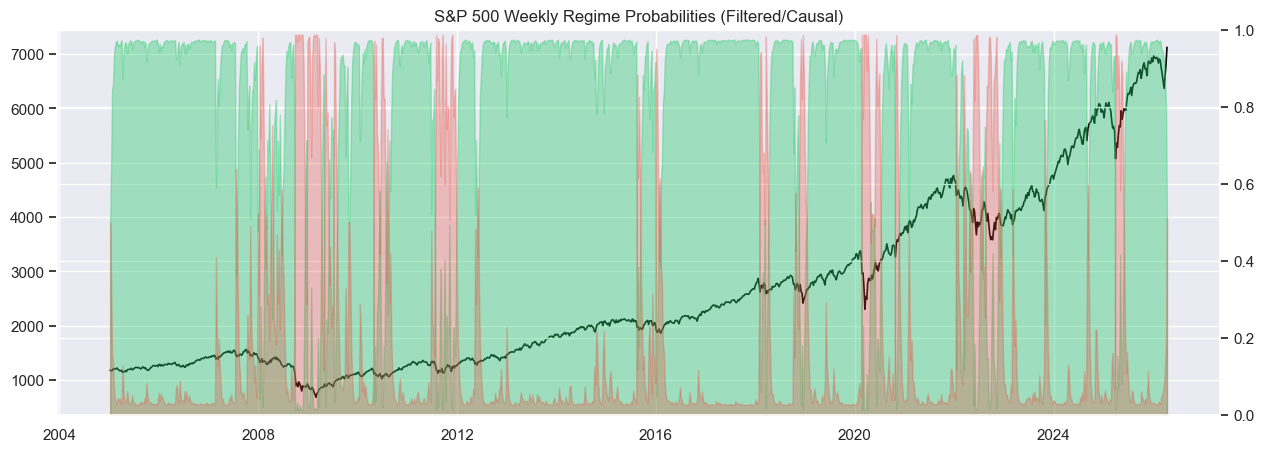

In [3]:
y_sp = sp500_df['Log_Return'].values
np.random.seed(42)
res_sp = gibbs_msm(y_sp, n_iter=2000, burn_in=500, a0=8.0, b0=2.0)

# Causal Filtered Probabilities
P_filt_avg_sp = np.mean(res_sp['P_filt'], axis=0)
P_bull_sp_filtered = P_filt_avg_sp[:, 1]

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(sp500_df.index, sp500_df['Close'], color='black', lw=1.2, label='S&P 500')
ax2 = ax1.twinx()
ax2.fill_between(sp500_df.index, 0, P_bull_sp_filtered, color='#2ecc71', alpha=0.4, label='P(Bull)')
ax2.fill_between(sp500_df.index, 0, 1-P_bull_sp_filtered, color='#e74c3c', alpha=0.3, label='P(Bear)')
ax2.set_ylim(0, 1)
plt.title('S&P 500 Weekly Regime Probabilities (Filtered/Causal)')
plt.show()

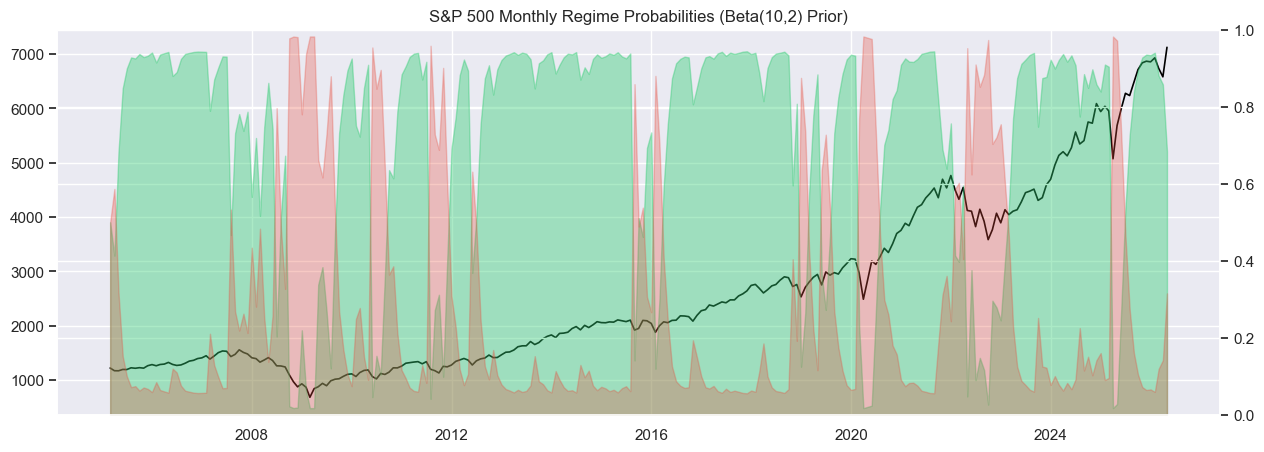

In [5]:
# Aggregate to monthly using fixed 'M' rule for pandas 2.x
sp500_monthly = sp500_df.resample('ME').agg({'Close': 'last'})
sp500_monthly['Log_Return'] = np.log(sp500_monthly['Close'] / sp500_monthly['Close'].shift(1))
sp500_monthly = sp500_monthly.dropna()

y_sp_m = sp500_monthly['Log_Return'].values
np.random.seed(42)
res_sp_m = gibbs_msm(y_sp_m, n_iter=2000, burn_in=500, a0=10.0, b0=2.0)

P_filt_avg_m = np.mean(res_sp_m['P_filt'], axis=0)
P_bull_sp_m_filtered = P_filt_avg_m[:, 1]

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(sp500_monthly.index, sp500_monthly['Close'], color='black', lw=1.2, label='S&P 500 (Monthly)')
ax2 = ax1.twinx()
ax2.fill_between(sp500_monthly.index, 0, P_bull_sp_m_filtered, color='#2ecc71', alpha=0.4, label='P(Bull)')
ax2.fill_between(sp500_monthly.index, 0, 1-P_bull_sp_m_filtered, color='#e74c3c', alpha=0.3, label='P(Bear)')
ax2.set_ylim(0, 1)
plt.title('S&P 500 Monthly Regime Probabilities (Beta(10,2) Prior)')
plt.show()

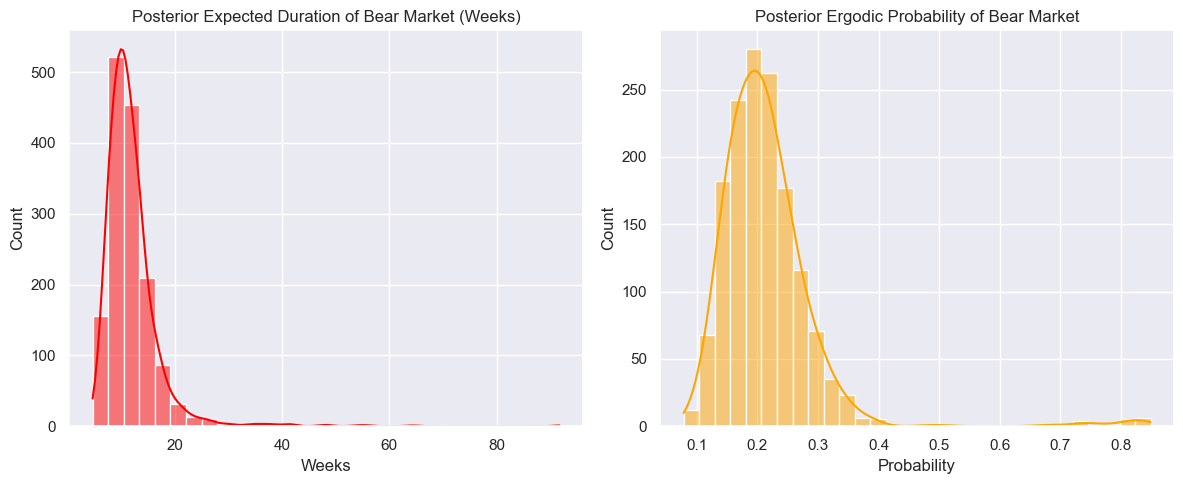

Mean Expected Bear Duration: 11.9 weeks
Mean Bear Ergodic Prob: 0.215


In [6]:
p_arr = np.array(res_sp['p'])
p00, p11 = p_arr[:,0], p_arr[:,1]

ED_bear = 1.0 / (1.0 - p00)
pi_bear = (1.0 - p11) / (2.0 - p00 - p11)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(ED_bear, bins=30, kde=True, ax=axes[0], color='red')
axes[0].set_title('Posterior Expected Duration of Bear Market (Weeks)')
axes[0].set_xlabel('Weeks')

sns.histplot(pi_bear, bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Posterior Ergodic Probability of Bear Market')
axes[1].set_xlabel('Probability')

plt.tight_layout()
plt.show()

print(f"Mean Expected Bear Duration: {ED_bear.mean():.1f} weeks")
print(f"Mean Bear Ergodic Prob: {pi_bear.mean():.3f}")